### Mutual Correlation Energy, Orbital Energy Decomposition

In [1]:
import forte2

In [2]:
from mutual_correlation_energy import fragment_decomposition_energy_enumerated
from mutual_correlation_energy import onefrag_correlation_energy_enumerated, twofrag_correlation_energy_enumerated, threefrag_correlation_energy_enumerated, fourfrag_correlation_energy_enumerated

from mutual_correlation_energy_mod_fast import twofrag_correlation_energy_enumerated as twofrag_correlation_energy_enumerated_mod

In [3]:
xyz = """
H 0.000 0.000 0.000
H 0.000 0.000 1.740
H 0.000 0.000 3.480
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVDZ", auxiliary_basis_set="cc-pVTZ-JKFIT")

rhf = forte2.ROHF(charge=0,ms=0.5)(system)
rhf.run()

ci=forte2.CI(forte2.State(system=system, multiplicity=2,ms=0.5),active_orbitals=[0,1,2,3,4,5,6,7])(rhf)
ci.run()

fragments = [[0, 1], [2, 3], [4, 5], [6, 7]]

result = fragment_decomposition_energy_enumerated(ci, fragments)

print("CI energy:           ", result["ci_energy"])
print("Decomposition energy:", result["decomposition_energy"])
print("Residual:            ", result["residual"])

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   H   0.00000000   0.00000000   0.00000000
   H   0.00000000   0.00000000   3.28812346
   H   0.00000000   0.00000000   6.57624691
Parsed 3 atoms with basis set of 15 functions.


  Max eigenvalue: 2.532e+00
  Min eigenvalue: 1.284e-01
  Condition number: 1.972e+01
  Inverse condition number: 5.071e-02
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 15
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 1.284e-01
Number of electrons: 3
Number of alpha electrons: 2
Number of beta electrons: 1
Ms: 0.5
Total charge: 0
Number of basis functions: 15
Number of orthogonalized basis functions: 15
Number of auxiliary basis functions: 90
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> ROHF SCF ROUTINE <==
Memory requirements: 0.00 GB (doubled due to storing B_nPm)
Number of system basis functions: 15
Number of auxiliary basis functions: 90
Iter               Energy           ΔE       ||ΔD||  ||AO grad||      <S^2>  DIIS
---------------------------------------------------------------------------------
   1      -1.443835177651  -1.0689e-02   2.1917e-01   7.0984e-02    0

In [ ]:
xyz = """
H 0.000 0.000 0.000
H 0.000 0.000 1.740
"""
system = forte2.System(xyz=xyz, basis_set="cc-pVDZ", auxiliary_basis_set="cc-pVTZ-JKFIT")

rhf = forte2.RHF(charge=0)(system)
rhf.run()

ci=forte2.CI(forte2.State(system=system, multiplicity=1,ms=0.0),active_orbitals=[0,1,2,3,4,5,6,7])(rhf)
ci.run()

fragments = [[0, 1], [2, 3], [4, 5], [6, 7]]

result = fragment_decomposition_energy_enumerated(ci, fragments)

print("CI energy:           ", result["ci_energy"])
print("Decomposition energy:", result["decomposition_energy"])
print("Residual:            ", result["residual"])

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   H   0.00000000   0.00000000   0.00000000
   H   0.00000000   0.00000000   3.28812346
Parsed 2 atoms with basis set of 10 functions.
  Max eigenvalue: 2.268e+00
  Min eigenvalue: 1.969e-01
  Condition number: 1.152e+01
  Inverse condition number: 8.683e-02
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 10


  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 1.969e-01
Number of electrons: 2
Number of alpha electrons: 1
Number of beta electrons: 1
Ms: 0
Total charge: 0
Number of basis functions: 10
Number of orthogonalized basis functions: 10
Number of auxiliary basis functions: 60
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.00 GB (doubled due to storing B_nPm)
Number of system basis functions: 10
Number of auxiliary basis functions: 60
Iter               Energy           ΔE       ||ΔD||  ||AO grad||      <S^2>  DIIS
---------------------------------------------------------------------------------
   1      -0.960429111551  -7.0124e-04   2.6631e-02   2.5316e-02    0.00000     S
   2      -0.960455422838  -2.6311e-05   6.2306e-03   4.8306e-03    0.00000   S/E
   3      -0.960455426123  -3.2852e-09   3.0424e-05   6.8500e-05    0.00000   S/E
   4      -0.9604554

In [5]:
xyz = """
H 0.000 0.000 -1.740
H 0.000 0.000 0.000
H 0.000 0.000 1.740
H 0.000 0.000 3.480
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.ROHF(charge=0, ms=1.0)(system)
rhf.run()

ci=forte2.CI(forte2.State(system=system, multiplicity=3,ms=1.0),active_orbitals=[0,1,2,3,4,5,6,7])(rhf)
ci.run()


frag_orbs = [0,1,2,3,4,5,6,7]

ints = forte2.jkbuilder.RestrictedMOIntegrals(
    system=ci.system,
    C=ci.C[0],
    orbitals=frag_orbs,
    core_orbitals=(),
)

Ecore = ints.E

E_A = onefrag_correlation_energy_enumerated(ci, [0,1])
E_B = onefrag_correlation_energy_enumerated(ci, [2,3])
E_C = onefrag_correlation_energy_enumerated(ci, [4,5])
E_D = onefrag_correlation_energy_enumerated(ci, [6,7])

E_AB = twofrag_correlation_energy_enumerated(ci, [0,1],[2,3])
E_AC = twofrag_correlation_energy_enumerated(ci, [0,1],[4,5])
E_AD = twofrag_correlation_energy_enumerated(ci, [0,1],[6,7])
E_BC = twofrag_correlation_energy_enumerated(ci, [2,3],[4,5])
E_BD = twofrag_correlation_energy_enumerated(ci, [2,3],[6,7])
E_CD = twofrag_correlation_energy_enumerated(ci, [4,5],[6,7])

E_ABC = threefrag_correlation_energy_enumerated(ci, [0,1],[2,3],[4,5])
E_ABD = threefrag_correlation_energy_enumerated(ci, [0,1],[2,3],[6,7])
E_ACD = threefrag_correlation_energy_enumerated(ci, [0,1],[4,5],[6,7])
E_BCD = threefrag_correlation_energy_enumerated(ci, [2,3],[4,5],[6,7])

E_ABCD = fourfrag_correlation_energy_enumerated(ci, [0,1],[2,3],[4,5],[6,7])

print(ci.E - Ecore - E_A - E_B -E_C -E_D -E_AB -E_AC - E_AD -E_BC -E_BD -E_CD -E_ABC -E_ABD -E_ACD - E_BCD)
print(E_ABCD)

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   H   0.00000000   0.00000000   -3.28812346
   H   0.00000000   0.00000000   0.00000000
   H   0.00000000   0.00000000   3.28812346
   H   0.00000000   0.00000000   6.57624691
Parsed 4 atoms with basis set of 56 functions.
  Max eigenvalue: 3.509e+00
  Min eigenvalue: 3.574e-02
  Condition number: 9.818e+01
  Inverse condition number: 1.019e-02
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 56
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 3.574e-02
Number of electrons: 4
Number of alpha electrons: 3
Number of beta electrons: 1
Ms: 1.0
Total charge: 0
Number of basis functions: 56
Number of orthogonalized basis functions: 56
Number of auxiliary basis functions: 72
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> ROHF SCF ROUTINE <==
Memory requirements: 0.00 GB (doubled due

In [ ]:
xyz = """
H 0.000 0.000 -1.740
H 0.000 0.000 0.000
H 0.000 0.000 1.740
H 0.000 0.000 3.480
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.ROHF(charge=0, ms=1.0)(system)
rhf.run()

ci=forte2.CI(forte2.State(system=system, multiplicity=3,ms=1.0),active_orbitals=[0,1,2,3,4,5,6,7])(rhf)
ci.run()


frag_orbs = [0,1,2,3,4,5,6,7]

ints = forte2.jkbuilder.RestrictedMOIntegrals(
    system=ci.system,
    C=ci.C[0],
    orbitals=frag_orbs,
    core_orbitals=(),
)

e = ints.E #core energy

for i in frag_orbs:
    e += onefrag_correlation_energy_enumerated(ci, [i])
    for j in frag_orbs:
        if j<i:
            e += twofrag_correlation_energy_enumerated(ci, [i], [j])
            for k in frag_orbs:
                if k<j:
                    e += threefrag_correlation_energy_enumerated(ci, [i], [j], [k])
                    for l in frag_orbs:
                        if l<k:
                            e += fourfrag_correlation_energy_enumerated(ci, [i], [j], [k], [l])

print(ci.E)
print(e)


Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   H   0.00000000   0.00000000   -3.28812346
   H   0.00000000   0.00000000   0.00000000
   H   0.00000000   0.00000000   3.28812346
   H   0.00000000   0.00000000   6.57624691
Parsed 4 atoms with basis set of 56 functions.
  Max eigenvalue: 3.509e+00
  Min eigenvalue: 3.574e-02
  Condition number: 9.818e+01
  Inverse condition number: 1.019e-02
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 56
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 3.574e-02
Number of electrons: 4
Number of alpha electrons: 3
Number of beta electrons: 1
Ms: 1.0
Total charge: 0
Number of basis functions: 56
Number of orthogonalized basis functions: 56
Number of auxiliary basis functions: 72
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> ROHF SCF ROUTINE <==
Memory requirements: 0.00 GB (doubled due

#### two frag visualization (adapted MCA code)

In [6]:
from plot_correlation_energy import mutual_correlation_plot

In [13]:
xyz = """
H 0.000 0.000 0.000
H 0.000 0.740 0.000
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.RHF(charge=0)(system)
rhf.run()

orb_list = [0,1,2,3,4,5,6,7,8,9]

hci=forte2.CI(forte2.State(system=system, multiplicity=1,ms=0),active_orbitals=orb_list)(rhf)
hci.run()

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   H   0.00000000   0.00000000   0.00000000
   H   0.00000000   1.39839733   0.00000000
Parsed 2 atoms with basis set of 28 functions.
  Max eigenvalue: 4.217e+00
  Min eigenvalue: 1.591e-03
  Condition number: 2.650e+03
  Inverse condition number: 3.774e-04
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 28
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 1.591e-03
Number of electrons: 2
Number of alpha electrons: 1
Number of beta electrons: 1
Ms: 0
Total charge: 0
Number of basis functions: 28
Number of orthogonalized basis functions: 28
Number of auxiliary basis functions: 36
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.00 GB (doubled due to storing B_nPm)
Number of system basis functions: 28
Number of auxiliary basis functions:

CI(states=State(multiplicity=1, ms=0, nel=2, system=System(atoms=[[1, array([0., 0., 0.])], [1, array([0.        , 1.39839733, 0.        ])]], basis_set=<Basis 'cc-pVTZ' with 28 basis functions>, auxiliary_basis_set=<Basis 'def2-universal-JKFIT' with 36 basis functions>), charge=0, gas_min=[], gas_max=[], symmetry=0, symmetry_label=None, na=1, nb=1, twice_ms=0), nroots=1, weights=[[1.0]], mo_space=MOSpace(nmo=28, active_orbitals=[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]], core_orbitals=[], frozen_core_orbitals=[], frozen_virtual_orbitals=[]), frozen_core_orbitals=None, core_orbitals=None, active_orbitals=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], frozen_virtual_orbitals=None, die_if_not_converged=True, first_run=False, executed=True, ci_params=CIParams(ci_algorithm='hz', ci_builder_memory=1024, energy_shift=None), davidson_liu_params=DavidsonLiuParams(guess_per_root=2, ndets_per_guess=10, collapse_per_root=2, basis_per_root=4, maxiter=100, e_tol=1e-12, r_tol=1e-06), do_test_rdms=False, log_level=3, final_o

In [17]:
import numpy as np

MCEmat = np.zeros((len(orb_list), len(orb_list)))

for ipos, iorb in enumerate(orb_list):
    for jpos, jorb in enumerate(orb_list):
        if ipos != jpos:
            MCEmat[ipos, jpos] = twofrag_correlation_energy_enumerated_mod(
                ci=hci,
                A_orbs=[iorb],
                B_orbs=[jorb],
            )
for i in range(0,len(MCEmat[0])):
    for j in range(0,len(MCEmat[0])):
        if j<i:
            if abs(MCEmat[i,j])> 0.005:
                print(f"Two fragment correlation of {[i]} and {[j]}: {MCEmat[i,j]}")

Two fragment correlation of [1] and [0]: -0.007931302919973543
Two fragment correlation of [2] and [0]: -0.0068628034729957075
Two fragment correlation of [3] and [0]: -0.01981776277769713
Two fragment correlation of [4] and [0]: -0.010485282806924666
Two fragment correlation of [5] and [0]: -0.010485282806924658



Generating cube files with the following parameters:
  Grid origin: (-4.000, -4.000, -4.000)
  Grid points: 40 x 47 x 40 points.
  Scaled axes: [(0.2, 0, 0), (0, 0.2, 0), (0, 0, 0.2)]
  Orbitals: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]



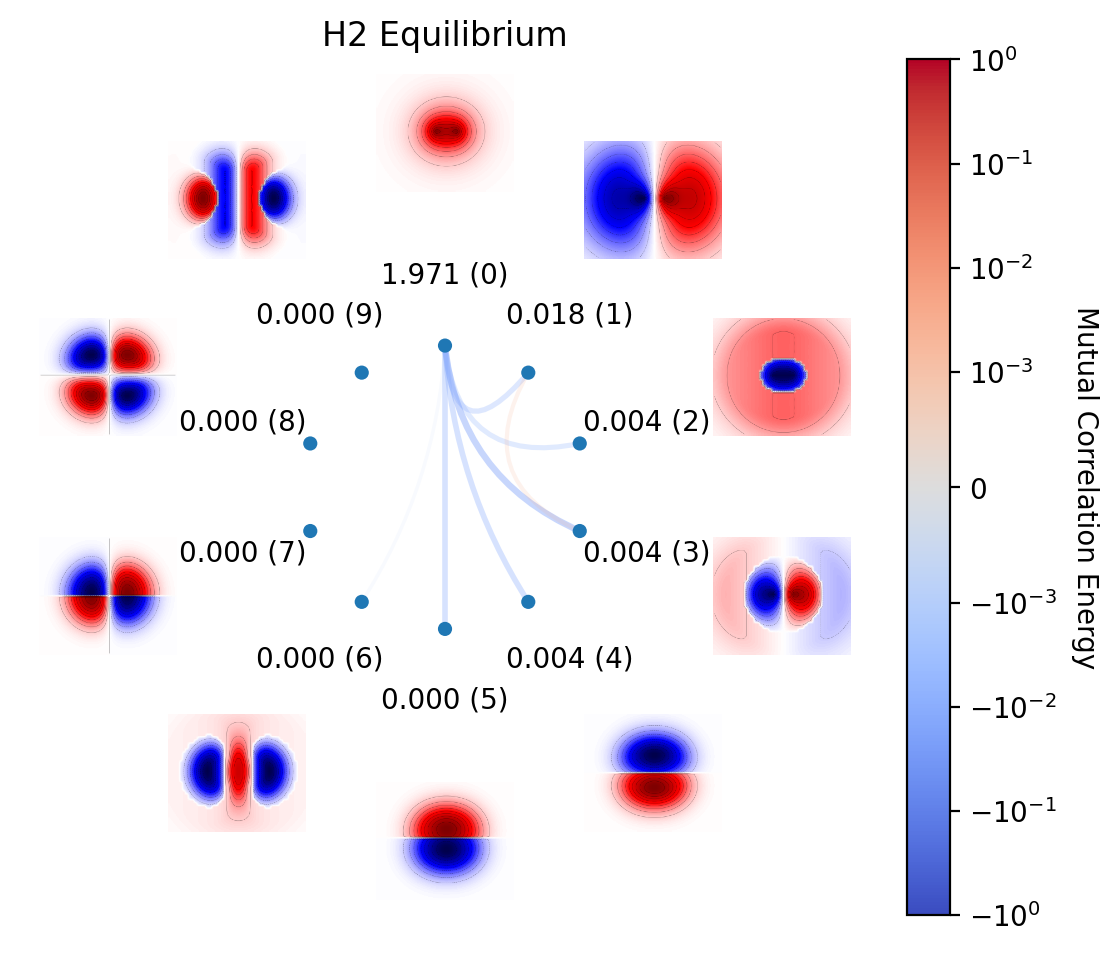

In [9]:
mutual_correlation_plot(system,hci.C[0],
                        indices=hci.mo_space.active_indices,
                        mca=MCEmat,
                        title="H2 Equilibrium",
                        occupation_numbers=hci.nat_occs,
                        output_file='h2_2cmod'
                        )

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   B   0.00000000   0.00000000   0.00000000
   B   0.00000000   3.00466454   0.00000000
Parsed 2 atoms with basis set of 60 functions.
  Max eigenvalue: 4.168e+00
  Min eigenvalue: 1.028e-03
  Condition number: 4.055e+03
  Inverse condition number: 2.466e-04
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 60
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 1.028e-03
Number of electrons: 10
Number of alpha electrons: 6
Number of beta electrons: 4
Ms: 1.0
Total charge: 0
Number of basis functions: 60
Number of orthogonalized basis functions: 60
Number of auxiliary basis functions: 150
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> ROHF SCF ROUTINE <==
Memory requirements: 0.01 GB (doubled due to storing B_nPm)
Number of system basis functions: 60
Number of auxiliary basis funct

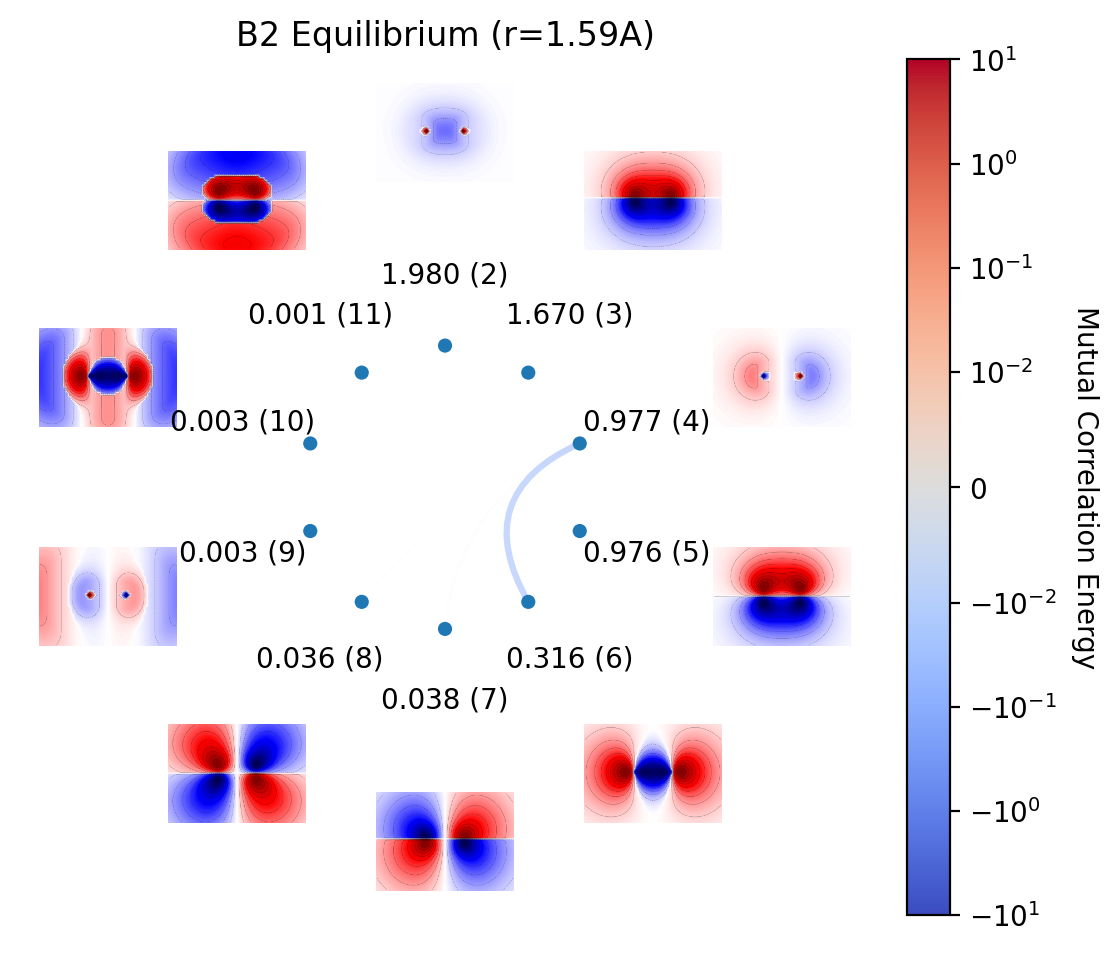

[[ 0.00000000e+00 -1.70805723e-03  3.06670476e-03 -1.68881967e-03
  -3.83142560e-03 -2.35146400e-03 -2.10823864e-03 -2.33228625e-04
  -6.47433179e-04 -9.59091726e-04]
 [-1.70805723e-03  0.00000000e+00  5.14367508e-03  1.41553620e-03
  -5.75699697e-03 -5.43642326e-03 -1.06984291e-03 -3.44328555e-05
  -4.84876604e-04  3.40272206e-06]
 [ 3.06670476e-03  5.14367508e-03  0.00000000e+00  4.88342154e-03
  -1.85195128e-01 -1.17535245e-02 -1.06477198e-02 -1.10320340e-03
  -6.90310482e-03 -2.57965408e-04]
 [-1.68881967e-03  1.41553620e-03  4.88342154e-03  0.00000000e+00
  -5.58216139e-03 -1.10667097e-03 -5.00966448e-03 -1.07238581e-04
  -5.63226314e-04 -1.32324566e-04]
 [-3.83142560e-03 -5.75699697e-03 -1.85195128e-01 -5.58216139e-03
   0.00000000e+00  5.09292868e-03  4.57220844e-03  6.24232821e-05
   9.58869475e-03  1.55821121e-04]
 [-2.35146400e-03 -5.43642326e-03 -1.17535245e-02 -1.10667097e-03
   5.09292868e-03  0.00000000e+00  9.42138293e-04  4.01597611e-05
   4.39887999e-04 -3.78658739e-06

In [10]:
xyz="""
B 0.000 0.000 0.000 
B 0.000 1.590 0.000
"""
orb_list = [2,3,4,5,6,7,8,9,10,11]

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.ROHF(charge=0, ms=1.0)(system)
rhf.run()

ci = forte2.CI(forte2.State(nel=10, multiplicity=3, ms=1.0),
    active_orbitals=orb_list,core_orbitals=[0,1])(rhf)
ci.run()

MCEmat = np.zeros((len(orb_list), len(orb_list)))

for ipos, iorb in enumerate(orb_list):
    for jpos, jorb in enumerate(orb_list):
        if ipos != jpos:
            MCEmat[ipos, jpos] = twofrag_correlation_energy_enumerated_mod(
                ci=ci,
                A_orbs=[iorb],
                B_orbs=[jorb],
                core_orbitals=[0,1]
            )

mutual_correlation_plot(system,ci.C[0],
                        indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="B2 Equilibrium (r=1.59A)",
                        vmax=10,
                        occupation_numbers=ci.nat_occs,
                        output_file='b2_eq_2cmod'
                        )
print(MCEmat)

In [11]:
xyz="""
C 0.000 0.000 0.000 
C 0.000 1.2545 0.000
"""
orb_list = [2,3,4,5,6,7,8,9,10,11]

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.RHF(charge=0)(system)
rhf.run()

ci = forte2.CI(forte2.State(nel=12, multiplicity=1, ms=0.0),
    active_orbitals=orb_list,core_orbitals=[0,1])(rhf)
ci.run()

MCEmat = np.zeros((len(orb_list),len(orb_list)))

for ipos, iorb in enumerate(orb_list):
    for jpos, jorb in enumerate(orb_list):
        if ipos != jpos:
            MCEmat[ipos, jpos] = twofrag_correlation_energy_enumerated_mod(
                ci=ci,
                A_orbs=[iorb],
                B_orbs=[jorb],
                core_orbitals=[0,1],
            )

mutual_correlation_plot(system,ci.C[0],indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="C2 Equilibrium (r=1.255A)",
                        vmax=10,
                        occupation_numbers=ci.nat_occs,
                        output_file='c2_eq_2cmod'
                        )
print(MCEmat)

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   C   0.00000000   0.00000000   0.00000000
   C   0.00000000   2.37066142   0.00000000
Parsed 2 atoms with basis set of 60 functions.
  Max eigenvalue: 4.146e+00
  Min eigenvalue: 9.478e-04
  Condition number: 4.374e+03
  Inverse condition number: 2.286e-04
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 60
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 9.478e-04
Number of electrons: 12
Number of alpha electrons: 6
Number of beta electrons: 6
Ms: 0
Total charge: 0
Number of basis functions: 60
Number of orthogonalized basis functions: 60
Number of auxiliary basis functions: 150
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.01 GB (doubled due to storing B_nPm)
Number of system basis functions: 60
Number of auxiliary basis function

KeyboardInterrupt: 

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   N   0.00000000   0.00000000   0.00000000
   N   0.00000000   2.07435237   0.00000000
Parsed 2 atoms with basis set of 60 functions.
  Max eigenvalue: 4.073e+00
  Min eigenvalue: 1.153e-03
  Condition number: 3.534e+03
  Inverse condition number: 2.830e-04
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 60
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 1.153e-03
Number of electrons: 14
Number of alpha electrons: 7
Number of beta electrons: 7
Ms: 0
Total charge: 0
Number of basis functions: 60
Number of orthogonalized basis functions: 60
Number of auxiliary basis functions: 154
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.01 GB (doubled due to storing B_nPm)
Number of system basis functions: 60
Number of auxiliary basis function

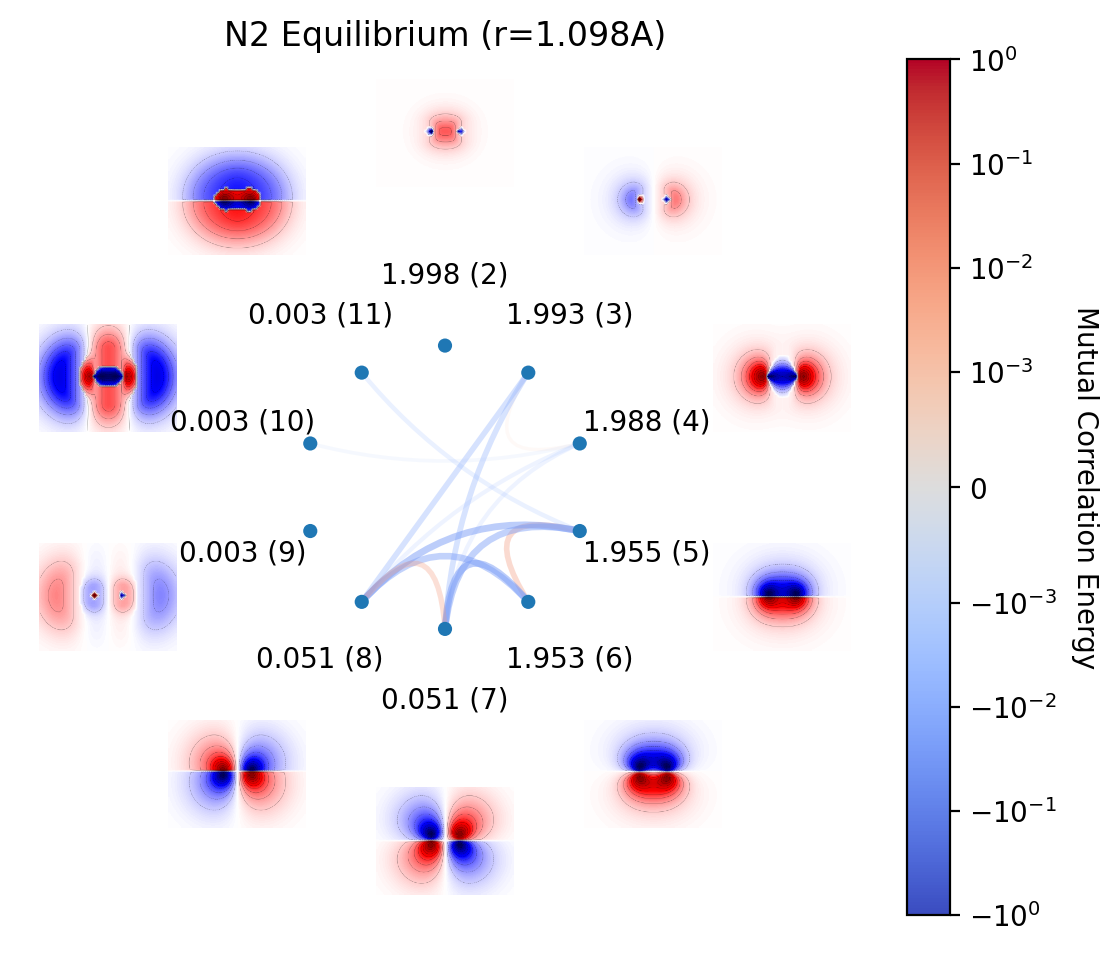

[[ 0.00000000e+00  2.49993060e-04  1.86398660e-04  5.61439707e-04
   4.82961222e-04 -8.89207386e-04 -9.38228449e-04 -3.27126995e-04
  -1.91749973e-04 -3.77010400e-04]
 [ 2.49993060e-04  0.00000000e+00  1.71652625e-03  9.02826928e-04
   6.51779733e-04 -1.03859430e-02 -1.04157075e-02 -9.54369791e-04
  -7.42917761e-04 -3.52784359e-04]
 [ 1.86398660e-04  1.71652625e-03  0.00000000e+00  7.43524405e-04
   2.65916491e-04 -3.26749167e-03 -3.28298469e-03 -6.02848788e-04
  -2.13452701e-03 -4.82132363e-04]
 [ 5.61439707e-04  9.02826928e-04  7.43524405e-04  0.00000000e+00
   1.04575054e-02 -2.34543624e-02 -2.88249627e-02 -3.76992928e-04
  -5.67710121e-04 -4.06412670e-03]
 [ 4.82961222e-04  6.51779733e-04  2.65916491e-04  1.04575054e-02
   0.00000000e+00 -2.93819362e-02 -2.36827186e-02 -2.29231332e-04
  -2.30626625e-04 -6.72700870e-05]
 [-8.89207386e-04 -1.03859430e-02 -3.26749167e-03 -2.34543624e-02
  -2.93819362e-02  0.00000000e+00  8.45269988e-03  2.05700383e-04
   1.61273109e-04  4.61798060e-05

In [ ]:
xyz="""
N 0.000 0.000 0.000 
N 0.000 1.0977 0.000
"""
orb_list = [2,3,4,5,6,7,8,9,10,11]

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.RHF(charge=0)(system)
rhf.run()

ci = forte2.CI(forte2.State(nel=14, multiplicity=1, ms=0.0),
    active_orbitals=orb_list,core_orbitals=[0,1])(rhf)
ci.run()

MCEmat = np.zeros((len(orb_list),len(orb_list)))

for ipos, iorb in enumerate(orb_list):
    for jpos, jorb in enumerate(orb_list):
        if ipos != jpos:
            MCEmat[ipos, jpos] = twofrag_correlation_energy_enumerated_mod(
                ci=ci,
                A_orbs=[iorb],
                B_orbs=[jorb],
                core_orbitals=[0,1],
            )

mutual_correlation_plot(system,ci.C[0],
                        indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="N2 Equilibrium (r=1.098A)",
                        vmax=1,
                        occupation_numbers=ci.nat_occs,
                        output_file='n2_eq_2cmod_rescaled'
                        )
print(MCEmat)

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   N   0.00000000   0.00000000   0.00000000
   N   0.00000000   5.85380462   0.00000000
Parsed 2 atoms with basis set of 60 functions.
  Max eigenvalue: 2.310e+00
  Min eigenvalue: 3.762e-02
  Condition number: 6.141e+01
  Inverse condition number: 1.628e-02
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 60
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 3.762e-02
Number of electrons: 14
Number of alpha electrons: 7
Number of beta electrons: 7
Ms: 0
Total charge: 0
Number of basis functions: 60
Number of orthogonalized basis functions: 60
Number of auxiliary basis functions: 154
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.01 GB (doubled due to storing B_nPm)
Number of system basis functions: 60
Number of auxiliary basis function

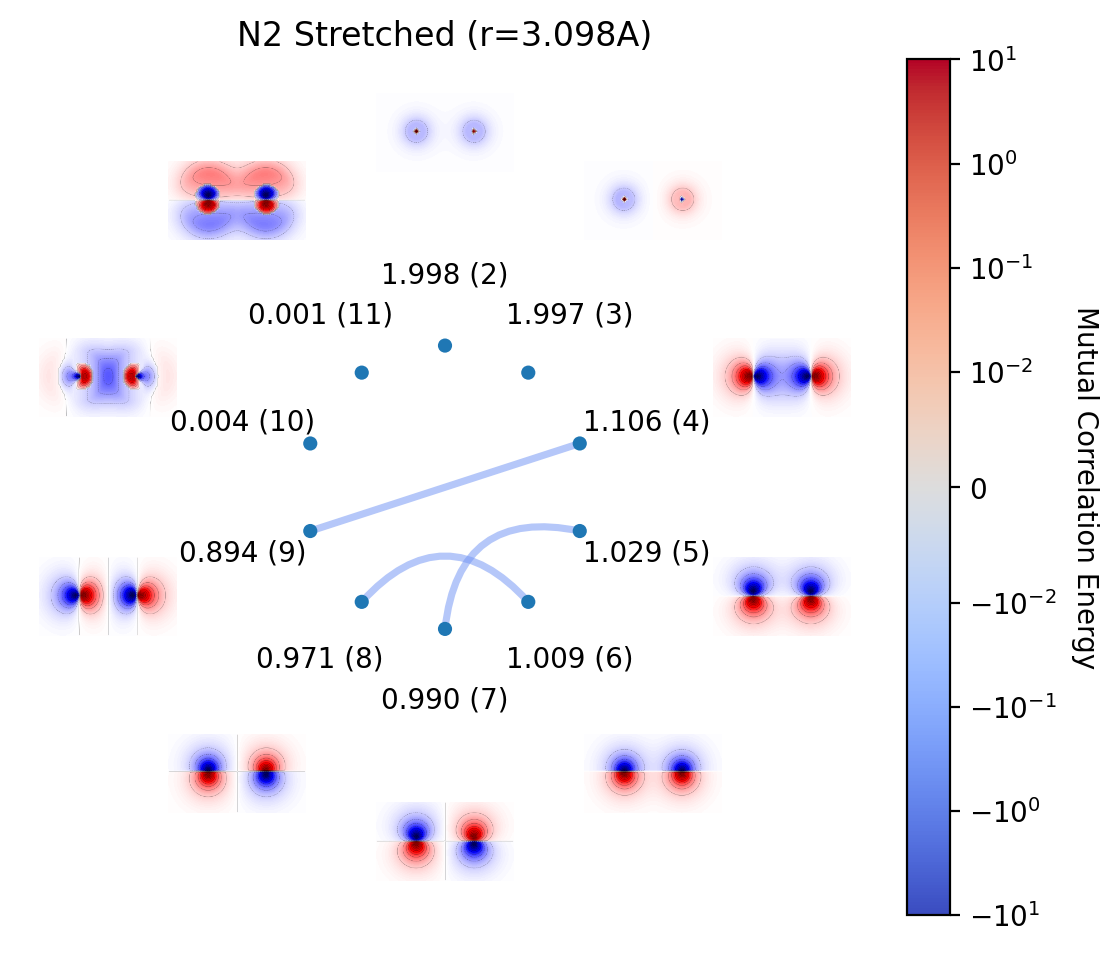

[[ 0.00000000e+00  5.92881796e-04  6.52137734e-05 -7.22082699e-05
  -6.08835517e-05  8.19148638e-05  6.88101876e-05 -1.18931433e-04
  -1.19968042e-03 -4.86325026e-04]
 [ 5.92881796e-04  0.00000000e+00  9.15202272e-05  3.68716295e-04
   3.41355697e-04 -2.89439734e-04 -2.80884446e-04 -1.09951272e-03
  -1.45378808e-03 -5.13538968e-04]
 [ 6.52137734e-05  9.15202272e-05  0.00000000e+00  2.87159341e-03
   3.23288255e-03  2.00063902e-03  1.70150933e-03 -3.80546670e-01
   1.91665664e-03  3.63853610e-05]
 [-7.22082699e-05  3.68716295e-04  2.87159341e-03  0.00000000e+00
   2.74504785e-03 -3.68198957e-01 -5.07298577e-03  2.27812479e-03
  -6.14008932e-05  2.43543341e-03]
 [-6.08835517e-05  3.41355697e-04  3.23288255e-03  2.74504785e-03
   0.00000000e+00 -5.14262962e-03 -3.71121921e-01  1.84909903e-03
   8.54416774e-05  3.11328964e-05]
 [ 8.19148638e-05 -2.89439734e-04  2.00063902e-03 -3.68198957e-01
  -5.14262962e-03  0.00000000e+00  2.87099012e-03  3.21364825e-03
  -4.12938132e-05 -1.43647187e-03

In [ ]:
xyz="""
N 0.000 0.000 0.000 
N 0.000 3.0977 0.000
"""
orb_list = [2,3,4,5,6,7,8,9,10,11]

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.RHF(charge=0)(system)
rhf.run()

ci = forte2.CI(forte2.State(nel=14, multiplicity=1, ms=0.0),
    active_orbitals=orb_list,core_orbitals=[0,1])(rhf)
ci.run()

MCEmat = np.zeros((len(orb_list),len(orb_list)))

for ipos, iorb in enumerate(orb_list):
    for jpos, jorb in enumerate(orb_list):
        if ipos != jpos:
            MCEmat[ipos, jpos] = twofrag_correlation_energy_enumerated_mod(
                ci=ci,
                A_orbs=[iorb],
                B_orbs=[jorb],
                core_orbitals=[0,1],
            )

mutual_correlation_plot(system,ci.C[0],
                        indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="N2 Stretched (r=3.098A)",
                        vmax=10,
                        occupation_numbers=ci.nat_occs,
                        output_file='n2_stretched_2cmod'
                        )
print(MCEmat)

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   O   0.00000000   0.00000000   0.00000000
   O   0.00000000   2.28184430   0.00000000
Parsed 2 atoms with basis set of 60 functions.
  Max eigenvalue: 3.735e+00
  Min eigenvalue: 4.428e-03
  Condition number: 8.434e+02
  Inverse condition number: 1.186e-03
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 60
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 4.428e-03
Number of electrons: 16
Number of alpha electrons: 9
Number of beta electrons: 7
Ms: 1.0
Total charge: 0
Number of basis functions: 60
Number of orthogonalized basis functions: 60
Number of auxiliary basis functions: 154
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> ROHF SCF ROUTINE <==
Memory requirements: 0.01 GB (doubled due to storing B_nPm)
Number of system basis functions: 60
Number of auxiliary basis funct

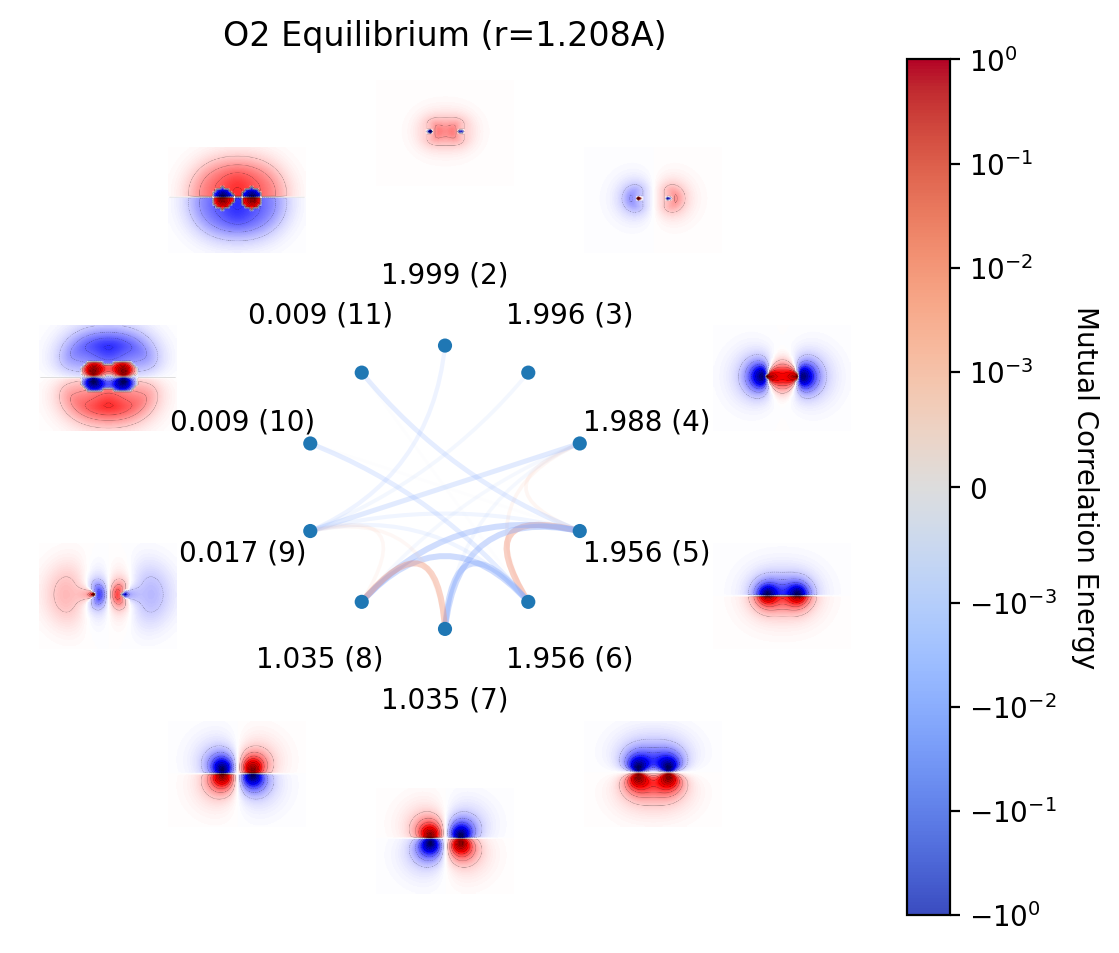

[[ 0.00000000e+00  2.07377459e-04  2.87425367e-04  8.40316029e-04
   8.40316034e-04 -6.32740593e-04 -6.32740574e-04 -3.26204685e-03
  -3.28890789e-04 -3.28890790e-04]
 [ 2.07377459e-04  0.00000000e+00  1.78618381e-04  2.74107470e-04
   2.74107471e-04  7.47888222e-05  7.47888420e-05 -2.35518558e-03
  -3.59522074e-04 -3.59522074e-04]
 [ 2.87425367e-04  1.78618381e-04  0.00000000e+00  2.14477349e-03
   2.14477347e-03 -2.09928814e-03 -2.09928817e-03 -6.53808389e-03
  -1.32935614e-04 -1.32935614e-04]
 [ 8.40316029e-04  2.74107470e-04  2.14477349e-03  0.00000000e+00
   1.62575251e-02 -1.45283813e-02 -1.39672397e-02 -2.92197206e-03
  -1.16512847e-03 -5.47659978e-03]
 [ 8.40316034e-04  2.74107471e-04  2.14477347e-03  1.62575251e-02
   0.00000000e+00 -1.39672397e-02 -1.45283813e-02 -2.92197205e-03
  -5.47659977e-03 -1.16512848e-03]
 [-6.32740593e-04  7.47888222e-05 -2.09928814e-03 -1.45283813e-02
  -1.39672397e-02  0.00000000e+00  1.45951299e-02  1.98117167e-03
   6.88261045e-05 -9.23066324e-05

In [ ]:
xyz="""
O 0.000 0.000 0.000 
O 0.000 1.2075 0.000
"""
orb_list = [2,3,4,5,6,7,8,9,10,11]

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.ROHF(charge=0, ms=1.0)(system)
rhf.run()

ci = forte2.CI(forte2.State(nel=16, multiplicity=3, ms=1.0),
    active_orbitals=orb_list,core_orbitals=[0,1])(rhf)
ci.run()

MCEmat = np.zeros((len(orb_list),len(orb_list)))

for ipos, iorb in enumerate(orb_list):
    for jpos, jorb in enumerate(orb_list):
        if ipos != jpos:
            MCEmat[ipos, jpos] = twofrag_correlation_energy_enumerated_mod(
                ci=ci,
                A_orbs=[iorb],
                B_orbs=[jorb],
                core_orbitals=[0,1],
            )

mutual_correlation_plot(system,ci.C[0],indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="O2 Equilibrium (r=1.208A)",
                        vmax=1,
                        occupation_numbers=ci.nat_occs,
                        output_file='o2_eq_2cmod_rescaled'
                        )
print(MCEmat)

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   F   0.00000000   0.00000000   0.00000000
   F   0.00000000   2.66829329   0.00000000
Parsed 2 atoms with basis set of 60 functions.
  Max eigenvalue: 3.206e+00
  Min eigenvalue: 1.535e-02
  Condition number: 2.089e+02
  Inverse condition number: 4.787e-03
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 60
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 1.535e-02
Number of electrons: 18
Number of alpha electrons: 9
Number of beta electrons: 9
Ms: 0
Total charge: 0
Number of basis functions: 60
Number of orthogonalized basis functions: 60
Number of auxiliary basis functions: 154
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.01 GB (doubled due to storing B_nPm)
Number of system basis functions: 60
Number of auxiliary basis function

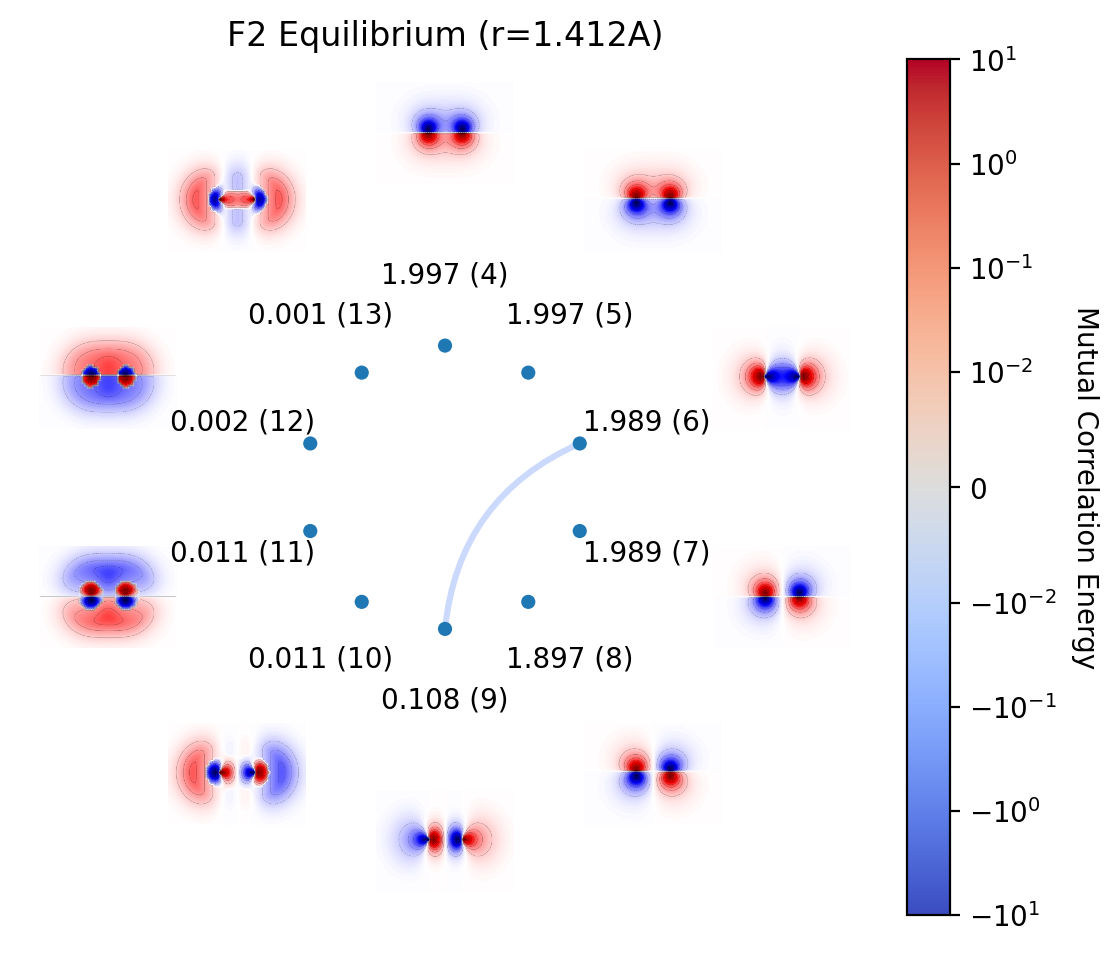

[[ 0.00000000e+00  5.85604848e-04  5.08120819e-04  7.51448059e-04
   6.89109649e-05 -9.03324467e-04 -9.03891393e-05 -2.66605168e-03
  -1.41129476e-03 -3.88630910e-04]
 [ 5.85604848e-04  0.00000000e+00  5.08120737e-04  6.89109453e-05
   7.51447940e-04 -9.03323497e-04 -9.03891331e-05 -1.41129477e-03
  -2.66605170e-03 -3.88630916e-04]
 [ 5.08120819e-04  5.08120737e-04  0.00000000e+00  3.57925952e-03
   3.57925958e-03 -1.67560682e-01 -8.95609121e-03 -2.73958831e-03
  -2.73958832e-03 -1.74460590e-03]
 [ 7.51448059e-04  6.89109453e-05  3.57925952e-03  0.00000000e+00
   7.93434773e-04 -8.54033887e-03 -7.13456644e-04 -4.06811857e-03
  -2.02338620e-03 -1.11334859e-04]
 [ 6.89109649e-05  7.51447940e-04  3.57925958e-03  7.93434773e-04
   0.00000000e+00 -8.54034148e-03 -7.13456709e-04 -2.02338622e-03
  -4.06811860e-03 -1.11334855e-04]
 [-9.03324467e-04 -9.03323497e-04 -1.67560682e-01 -8.54033887e-03
  -8.54034148e-03  0.00000000e+00  9.61470080e-03  1.88073824e-03
   1.88073825e-03  2.05558738e-04

In [ ]:
xyz="""
F 0.000 0.000 0.000 
F 0.000 1.412 0.000
"""
orb_list = [4,5,6,7,8,9,10,11,12,13]

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.RHF(charge=0)(system)
rhf.run()

ci = forte2.CI(forte2.State(nel=18, multiplicity=1, ms=0.0),
    active_orbitals=orb_list,core_orbitals=[0,1,2,3])(rhf)
ci.run()

MCEmat = np.zeros((len(orb_list),len(orb_list)))

for ipos, iorb in enumerate(orb_list):
    for jpos, jorb in enumerate(orb_list):
        if ipos != jpos:
            MCEmat[ipos, jpos] = twofrag_correlation_energy_enumerated_mod(
                ci=ci,
                A_orbs=[iorb],
                B_orbs=[jorb],
                core_orbitals=[0,1,2,3],
            )

mutual_correlation_plot(system,ci.C[0],indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="F2 Equilibrium (r=1.412A)",
                        vmax=10,
                        occupation_numbers=ci.nat_occs,
                        output_file='f2_eq_2cmod'
                        )
print(MCEmat)

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   F   0.00000000   0.00000000   0.00000000
   F   0.00000000   5.66917837   0.00000000
Parsed 2 atoms with basis set of 60 functions.
  Max eigenvalue: 2.228e+00
  Min eigenvalue: 4.167e-02
  Condition number: 5.346e+01
  Inverse condition number: 1.870e-02
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 60
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 4.167e-02
Number of electrons: 18
Number of alpha electrons: 9
Number of beta electrons: 9
Ms: 0
Total charge: 0
Number of basis functions: 60
Number of orthogonalized basis functions: 60
Number of auxiliary basis functions: 154
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.01 GB (doubled due to storing B_nPm)
Number of system basis functions: 60
Number of auxiliary basis function

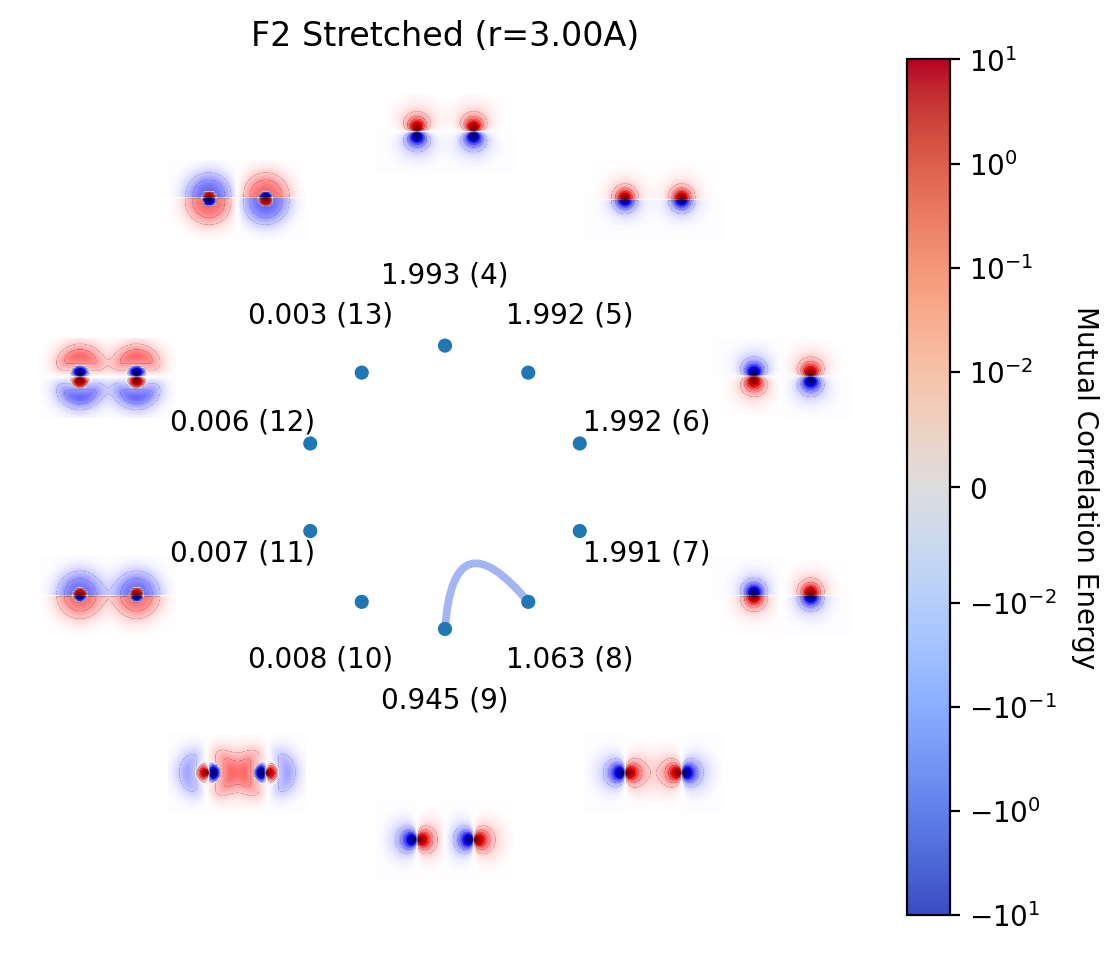

[[ 0.00000000e+00  6.74895576e-04 -4.20140123e-04  3.02825823e-04
  -2.65010723e-03 -3.49825746e-04 -3.76606872e-04 -4.75752182e-04
  -3.38721125e-03 -6.38271531e-04]
 [ 6.74895576e-04  0.00000000e+00  6.10993660e-04  1.95291189e-03
  -3.04955392e-04  2.53031037e-04 -5.14682908e-04 -4.59201789e-03
  -6.96965435e-04 -3.93113899e-03]
 [-4.20140123e-04  6.10993660e-04  0.00000000e+00  9.62904741e-04
  -3.13084903e-04 -3.27688854e-03 -3.12551222e-04 -8.89734894e-04
  -3.04384884e-03 -1.23842840e-03]
 [ 3.02825823e-04  1.95291189e-03  9.62904741e-04  0.00000000e+00
   1.95488752e-04 -1.76919260e-03 -4.22829484e-04 -3.79634946e-03
  -8.54865144e-04 -2.93297198e-03]
 [-2.65010723e-03 -3.04955392e-04 -3.13084903e-04  1.95488752e-04
   0.00000000e+00 -6.65902330e-01  1.08439961e-02 -2.64716403e-04
  -2.09359278e-04 -2.59465286e-04]
 [-3.49825746e-04  2.53031037e-04 -3.27688854e-03 -1.76919260e-03
  -6.65902330e-01  0.00000000e+00 -3.71593948e-03 -1.02572817e-04
  -1.00542574e-04 -9.22636756e-05

In [ ]:
xyz="""
F 0.000 0.000 0.000 
F 0.000 3.00 0.000
"""
orb_list = [4,5,6,7,8,9,10,11,12,13]

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.RHF(charge=0)(system)
rhf.run()

ci = forte2.CI(forte2.State(nel=18, multiplicity=1, ms=0.0),
    active_orbitals=orb_list,core_orbitals=[0,1,2,3])(rhf)
ci.run()

MCEmat = np.zeros((len(orb_list),len(orb_list)))

for ipos, iorb in enumerate(orb_list):
    for jpos, jorb in enumerate(orb_list):
        if ipos != jpos:
            MCEmat[ipos, jpos] = twofrag_correlation_energy_enumerated_mod(
                ci=ci,
                A_orbs=[iorb],
                B_orbs=[jorb],
                core_orbitals=[0,1,2,3],
            )

mutual_correlation_plot(system,ci.C[0],indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="F2 Stretched (r=3.00A)",
                        vmax=10,
                        occupation_numbers=ci.nat_occs,
                        output_file='f2_stretched_2cmod'
                        ) 
print(MCEmat)

In [ ]:
MCEmat = np.zeros((len(orb_list)))

for ipos, iorb in enumerate(orb_list):
        MCEmat[ipos] = onefrag_correlation_energy_enumerated(
            ci=ci,
            A_orbs=[iorb],
            core_orbitals=[0,1],
            )
        
print(MCEmat)

[-13.14282052 -13.14039017 -13.15373759 -13.15473626  -6.72630353
  -6.12094116  -0.05300592  -0.03270604  -0.02762878  -0.03107381]
